In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/nfs/home/svu/e1498138/localgit/FEWNEW/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_phasemax_noise import LogLike
import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 10
T = 3/12
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 5 #scale by 2-3x
qS = np.pi
phiS = 0.
qK = 0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')

data_snr = float(gwf.rhostat_timemax(loglike_obj.signal).get())
print(f'SNR (time-max): {data_snr:.4f}')


def log_density(params):
    params = np.asarray(params)
    log_likes = np.zeros(params.shape[0])
    for i in range(params.shape[0]):
        logm1, logm2, a, p0, e0 = params[i]
        try:
            loglike = loglike_obj(np.array([
                10**logm1, 10**logm2, a, p0, e0,
                xI0, dist, qS, phiS, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0
            ]))
        except Exception:
            loglike = -np.inf
        log_likes[i] = loglike
    return log_likes


def prior_transform(u):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    return u

Using dt=10s, T=0.25yr, TDI gen=1
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.
SNR (time-max): 1539.1741


In [ ]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paris1_noise/int_3mth_noise_6'


In [ ]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')

In [4]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [5]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[ 0.75515   ,  0.21455   ,  0.27275   ,  0.93015   ,  0.48525   ],
        [ 0.75514844,  0.21453699,  0.27273934,  0.93014767,  0.48525859],
        [ 0.75513359,  0.21454499,  0.27272725,  0.93015259,  0.48525732],
        ...,
        [ 0.0564315 ,  0.21508276,  0.16926917,  0.49188687,  0.96588146],
        [-0.07955314,  0.19269811,  0.39607791,  1.13235316,  1.218227  ],
        [ 0.97246973,  0.31518002,  1.10814207, -0.42030627,  1.28731015]],
       shape=(5000, 5))]

In [6]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([3.04810304, 3.06434847, 3.05863426, ..., 0.08026683,       -inf,
              -inf], shape=(5000,))]

In [7]:
sampler.now_covariances

[array([[ 0.01636297,  0.01383464,  0.00236962, -0.03878375,  0.00725145],
        [ 0.01383464,  0.1463815 , -0.00206735,  0.05026345, -0.04570604],
        [ 0.00236962, -0.00206735,  0.09382289, -0.02435685, -0.00654105],
        [-0.03878375,  0.05026345, -0.02435685,  0.3254961 , -0.03001291],
        [ 0.00725145, -0.04570604, -0.00654105, -0.03001291,  0.15216552]])]

In [8]:
np.argmax(logden_list)

np.int64(2227)

In [9]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[ 6.20195789,  0.9089965 ,  0.47669638, 10.82748525,  0.34877658]])

In [10]:
log_density(maxld_pt1)

array([4.00823559])

In [11]:
log_density([param_true])

array([8.24192844])

In [12]:
param_ranges = [(5.6,6.4),
                (0.8,1.3),
                (0.3,0.99),
                (8.0,11.0),
                (0.2,0.5),
                ]
param_ranges

[(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

In [13]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]
param_true

[np.float64(6.0), np.float64(1.0), 0.7, 9, 0.4]

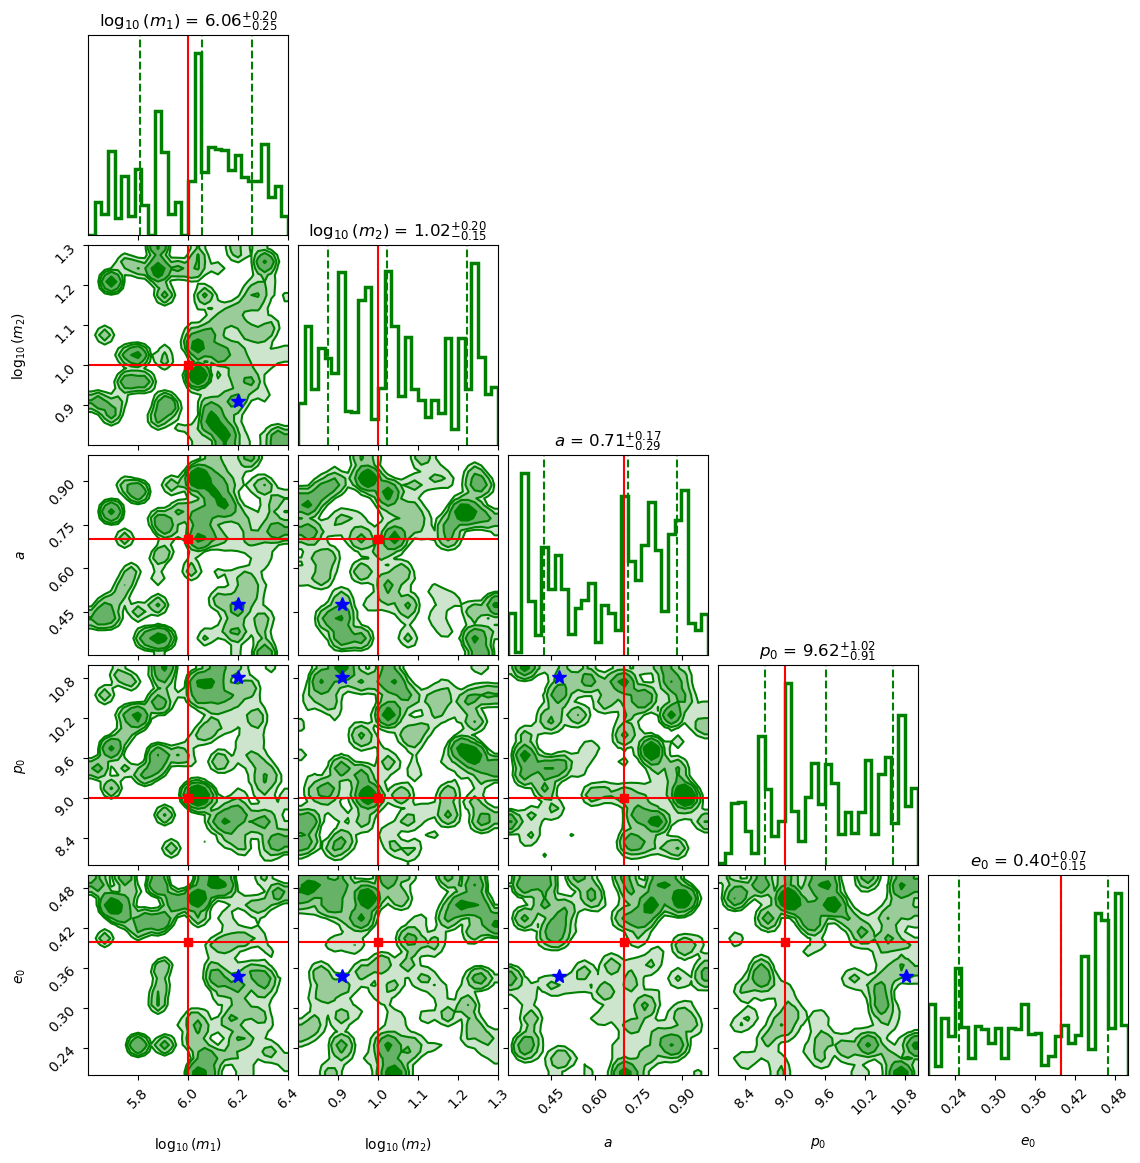

In [14]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$T$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




In [15]:
np.sort(logden_list)

array([[      -inf,       -inf,       -inf, ..., 3.61053123, 3.78157601,
        4.00823559]], shape=(1, 5000))

In [16]:
top10_idx = np.argsort(logden_list).flatten()[-10:][::-1]
top10_idx

array([2227, 2560, 2367, 1727, 1316, 2526,  896,  989, 1465, 2693])

In [17]:
top10_pts = prior_transform(proc_pt[0][top10_idx])
top10_pts

array([[ 6.20195789,  0.9089965 ,  0.47669638, 10.82748525,  0.34877658],
       [ 6.20704808,  0.90441345,  0.49808486, 10.69721173,  0.34700917],
       [ 6.20275245,  0.90388545,  0.48060288, 10.80486559,  0.34885236],
       [ 6.20544229,  0.90770607,  0.49100322, 10.77673207,  0.34429274],
       [ 6.20441581,  0.90748573,  0.48920963, 10.78693132,  0.3453536 ],
       [ 6.20088995,  0.89636764,  0.47258505, 10.75211501,  0.35529309],
       [ 6.20409788,  0.90716156,  0.48829202, 10.7909818 ,  0.34554413],
       [ 6.2041078 ,  0.90723481,  0.48837789, 10.79046769,  0.34559964],
       [ 6.20420488,  0.90668974,  0.48847446, 10.78930734,  0.34550796],
       [ 6.18821691,  0.89472763,  0.41379146, 10.92690896,  0.36857035]])

In [ ]:
ranges = [                                                                                                                                                                         
    (5.6, 6.4),                                                                                                                                                                    
    (0.8, 1.3),                                                                                                                                                                    
    (0.3, 0.99),                                                                                                                                                                   
    (8.0, 11.0),                                                                                                                                                                 
    (0.2, 0.5),
]       

In [ ]:
labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$']                                                                                                        
true_params = np.array([6.0, 1.0, 0.7, 9.0, 0.4])
ndim = 5                                                                                                                                                                           
            

In [ ]:
import matplotlib.pyplot as plt

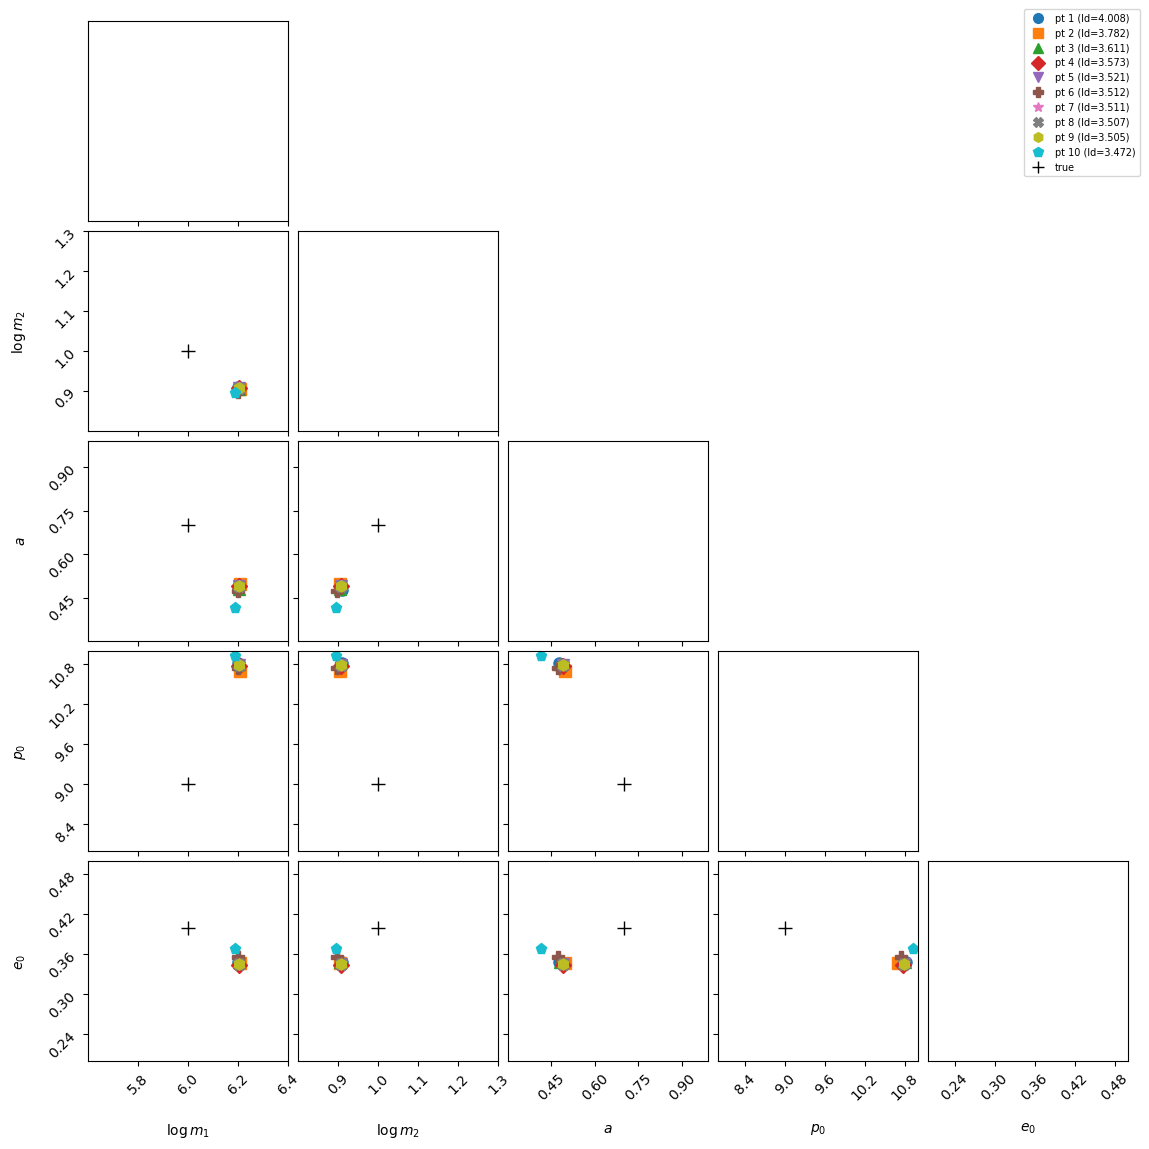

In [21]:
_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
markers_list = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h', 'p']

all_pts = np.vstack([top10_pts, [true_params]])
fig = corner.corner(all_pts, labels=labels, show_titles=False,
                    plot_datapoints=False, plot_density=False, plot_contours=False, ranges=ranges,
                    hist_kwargs=dict(alpha=0, lw=0))

for i, pt in enumerate(top10_pts):
    corner.overplot_points(fig, pt.reshape(1, -1), color=_cycle[i % len(_cycle)], marker=markers_list[i], ms=8)

corner.overplot_points(fig, np.array([true_params]), color='black', marker='+', ms=10)

# Re-enforce ranges
axes = np.array(fig.axes).reshape((ndim, ndim))
for row in range(ndim):
    for col in range(ndim):
        if col <= row:
            axes[row, col].set_xlim(ranges[col])
        if col < row:
            axes[row, col].set_ylim(ranges[row])

from matplotlib.lines import Line2D
ld_vals = np.concatenate(logden_list)[top10_idx]
handles = [Line2D([0],[0], color=_cycle[i % len(_cycle)], marker=markers_list[i], ls='', ms=7,
                label=f"pt {i+1} (ld={ld_vals[i]:.3f})")
            for i in range(10)]
handles.append(Line2D([0],[0], color='black', marker='+', ls='', ms=8, label='true'))
fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=7)
plt.show()

# connection plot

In [22]:
proc1_maxld_pt = maxld_pt1.copy()
proc1_maxld_pt

array([[ 6.20195789,  0.9089965 ,  0.47669638, 10.82748525,  0.34877658]])

In [23]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [24]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [25]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


In [26]:
logden_theory_proc1

array([4.00823559, 0.16525611, 1.46797168, 2.25270113, 0.98423579,
       0.69990785, 1.35980345, 0.30854412, 0.51813255, 0.72168757,
       0.38066887, 0.81055418, 1.02935817, 0.35270494, 0.72808982,
       0.61669403, 0.66252673, 0.91894947, 0.53416783, 0.83690631,
       0.90259412, 0.62514175, 0.16255339, 0.64546863, 0.7287452 ,
       0.35902865, 0.69016464, 0.19597333, 0.48917186, 0.7032857 ,
       1.86281105, 0.27547579, 0.08422452, 0.90167176, 0.36127646,
       0.94243022, 0.0861371 , 0.34093025, 0.20029875, 0.33034231,
       0.57203797, 0.56894266, 0.17320568, 0.05752701, 0.20828465,
       0.14425998, 0.50184486, 0.27340645, 0.20392701, 8.24192844])

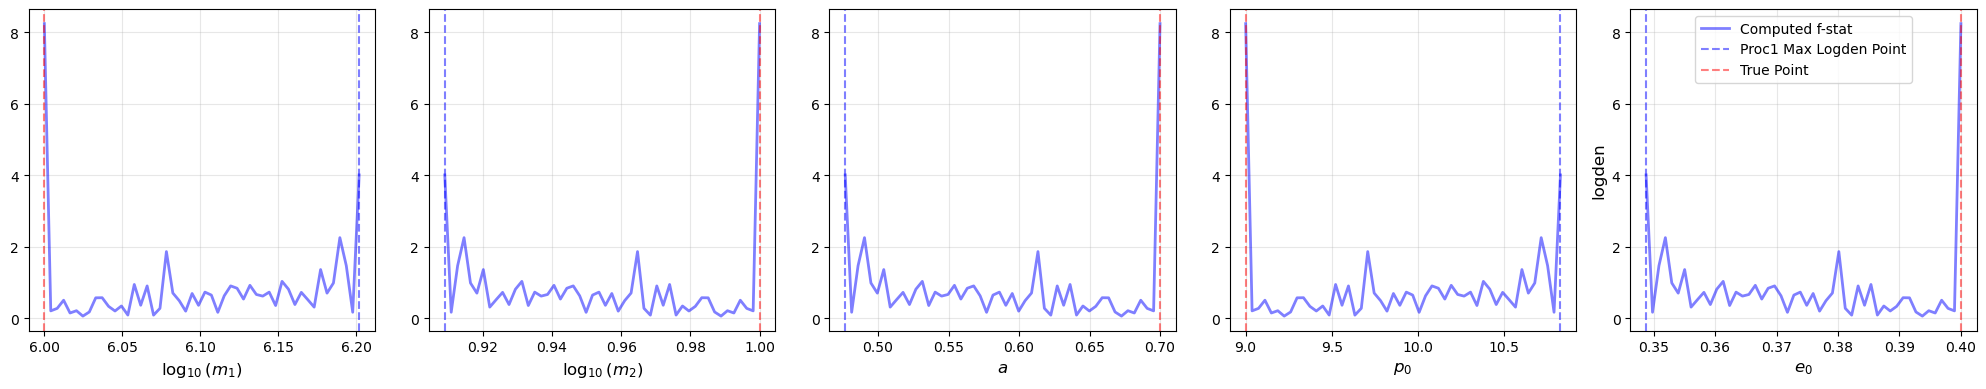

In [27]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$T$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()
